# Credit Scoring Model - Exploratory Data Analysis

**Goal:**
Understand the dataset before preprocessing and model training.

**Dataset Size:** 32,581 rows × 12 columns

In [8]:
import pandas as pd
import numpy as np 

In [9]:
df = pd.read_csv("../data/raw/credit_data.csv")

In [10]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


#### Understand Functions and analyze data 

In [11]:
df.shape
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [12]:
df.tail()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


In [13]:
df.columns()

TypeError: 'Index' object is not callable

In [ ]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='str')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.5 MB


In [ ]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [ ]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Observation:
The dataset contains missing values in two columns:

person_emp_length has 895 missing values.
loan_int_rate has 3,116 missing values.
All remaining columns have no missing values. These missing values will need to be handled during the data preprocessing stage before model training.

In [ ]:
df.duplicated().sum()

np.int64(165)

Interpretation 📊

Your dataset has:

32,581 total rows
165 duplicate rows

In [ ]:
df["loan_status"].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

0 appears 23473 times and 1 appears 7108 times

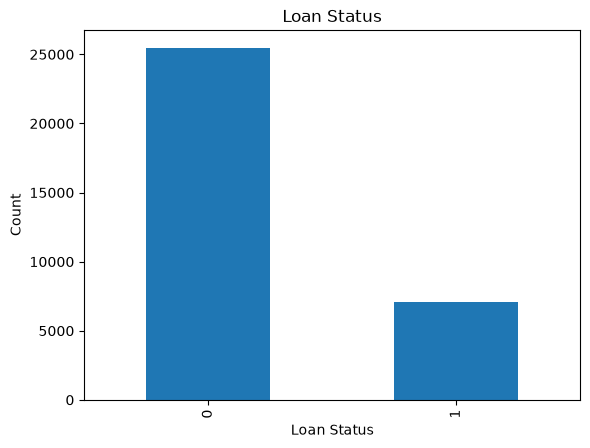

In [ ]:
import matplotlib.pyplot as plt 
df["loan_status"].value_counts().plot(kind="bar")
plt.title("Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()


Observation:
The target variable loan_status is imbalanced. Class 0 has 25,473 (78.2%) records, while Class 1 has 7,108 (21.8%) records. Since the majority of the data belongs to Class 0, the dataset is not balanced. This class imbalance should be considered during model training and evaluation.

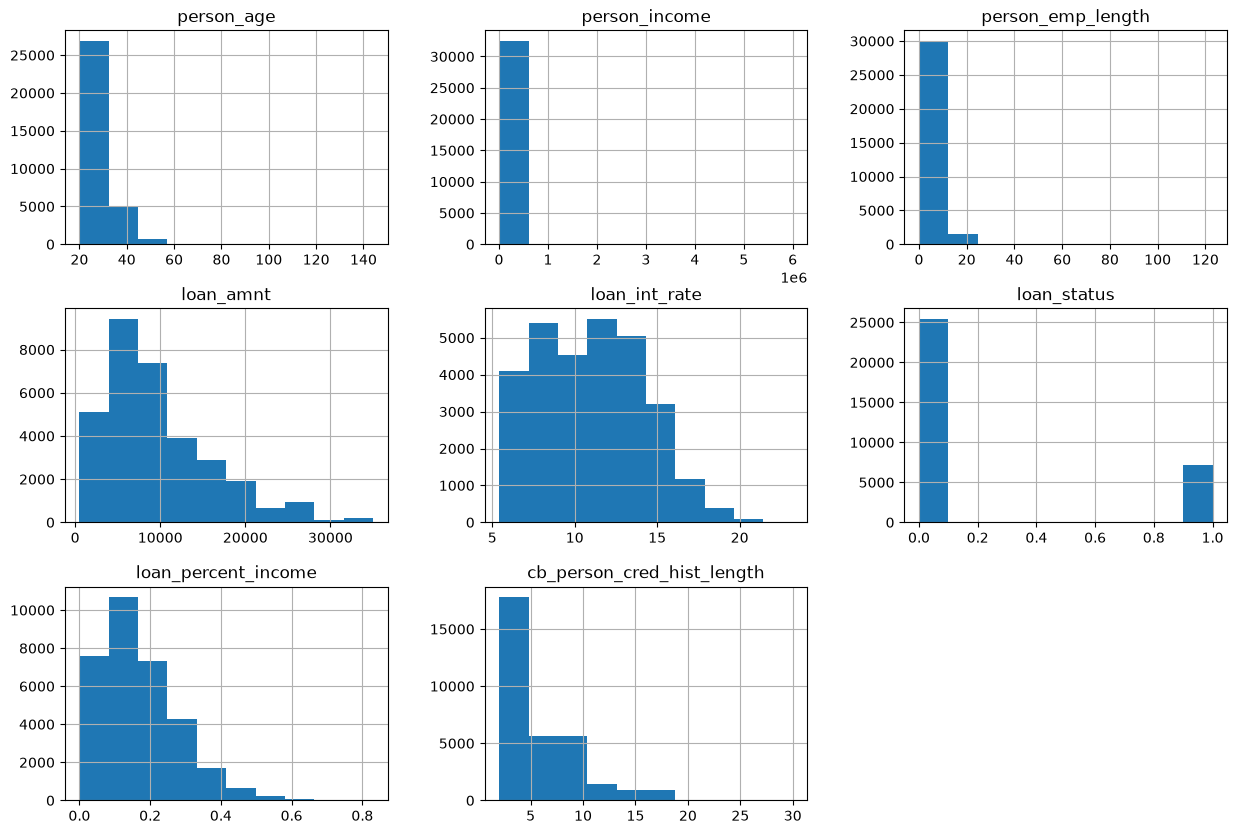

In [ ]:
df.hist(figsize=(15,10))
plt.show()

Observations from histograms:
Most borrowers are between 20 and 40 years old. The distribution is right-skewed with a few unusually high age values, indicating possible outliers.
The income distribution is highly right-skewed. Most customers have relatively low incomes, while a few have extremely high incomes that may represent outliers.
Employment length is right-skewed. Most borrowers have fewer than 10 years of employment, while a few records show extremely large employment lengths, suggesting possible data errors or outliers.
Loan amounts are right-skewed. Most loans are relatively small, while a few customers have much larger loan amounts.
Interest rates appear approximately normally distributed with no obvious extreme values.
Loan percentage of income is right-skewed. Most borrowers spend a relatively small proportion of their income on loans, while a few have very high loan-to-income ratios.
Credit history length is right-skewed. Most borrowers have relatively short credit histories, while a small number have much longer histories.
2. Do you notice any unusual values?

✅ Yes.

Very high ages (around 140 years)
Extremely high incomes
Unrealistic employment lengths (up to ~120 years)
Some very large loan amounts

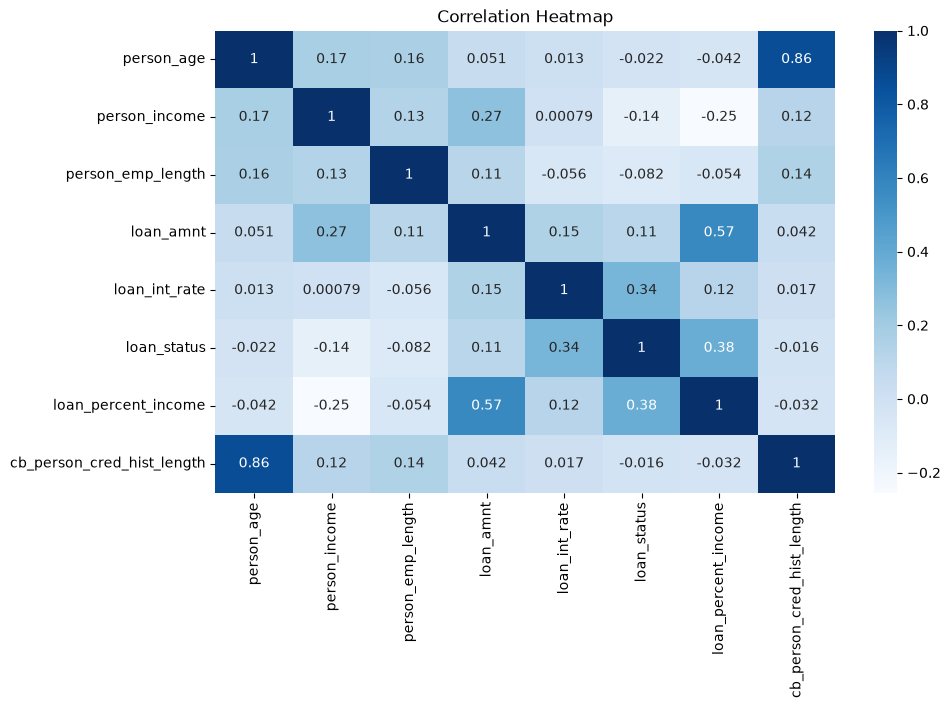

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt 

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show() 

Observation from heatmap:
There is a strong positive correlation (0.86) between person_age and cb_person_cred_hist_length, indicating that older borrowers tend to have longer credit histories.
loan_amnt and loan_percent_income have a moderate positive correlation (0.57). Larger loan amounts are generally associated with higher loan-to-income ratios.
loan_percent_income has a positive correlation (0.38) with loan_status, suggesting that borrowers with higher loan-to-income ratios may have a higher likelihood of loan default.
loan_int_rate shows a moderate positive correlation (0.34) with loan_status, indicating that borrowers with higher interest rates tend to default more often.
person_income has a weak negative correlation (-0.25) with loan_percent_income, meaning higher-income borrowers generally spend a smaller proportion of their income on loans.
Observation:
The correlation heatmap shows that most numerical features have weak to moderate correlations. The strongest positive correlation is between person_age and cb_person_cred_hist_length (0.86), indicating that older borrowers tend to have longer credit histories. loan_amnt and loan_percent_income have a moderate positive correlation (0.57). With respect to the target variable (loan_status), loan_percent_income (0.38) and loan_int_rate (0.34) have the strongest positive correlations, while most other features show weak linear relationships.

## Observations

- Dataset contains **32,581 rows and 12 columns**.
- Missing values found in **`person_emp_length` (895) and `loan_int_rate` (3,116)**.
- Duplicate rows: **165**.
- Target variable is **imbalanced** (Class 0: 78.2%, Class 1: 21.8%).
- Highest correlation: **`person_age` and `cb_person_cred_hist_length` (0.86)**.
- Interesting observation: **Most numerical features are right-skewed with several potential outliers (e.g., age = 144 years, employment length = 123 years, and very high incomes). Also, `loan_percent_income` and `loan_int_rate` show the strongest positive relationships with the target variable (`loan_status`).**

#### Data Preprocessing

In [ ]:
df[['person_emp_length', 'loan_int_rate']].isnull().sum()

person_emp_length     895
loan_int_rate        3116
dtype: int64

In [ ]:
missing_percentage = (df[['person_emp_length', 'loan_int_rate']].isnull().sum()) / len(df) * 100
missing_percentage

person_emp_length    2.747000
loan_int_rate        9.563856
dtype: float64

In [ ]:
df['person_emp_length'].describe()

count    31686.000000
mean         4.789686
std          4.142630
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max        123.000000
Name: person_emp_length, dtype: float64

In [ ]:
df['person_emp_length'].median()

np.float64(4.0)

In [ ]:
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

In [ ]:
df['person_emp_length'].isnull().sum()

np.int64(0)

In [ ]:
df['person_emp_length'].describe()

count    32581.000000
mean         4.767994
std          4.087372
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max        123.000000
Name: person_emp_length, dtype: float64

person_emp_length contained 895 missing values (2.75%). The feature had a right-skewed distribution and an extreme maximum value of 123 years. Since the median (4 years) is less affected by extreme values than the mean (4.79 years), the missing values were imputed using the median. After imputation, no missing values remained.

In [ ]:
df['loan_int_rate'].describe()

count    29465.000000
mean        11.011695
std          3.240459
min          5.420000
25%          7.900000
50%         10.990000
75%         13.470000
max         23.220000
Name: loan_int_rate, dtype: float64

In [ ]:
df.groupby('loan_grade')['loan_int_rate'].agg(
    ['count', 'mean', 'median']
)

,count,mean,median
loan_grade,,,
A,9774,7.327651,7.490
B,9395,10.995555,10.990
C,5828,13.463542,13.480
D,3314,15.361448,15.310
E,881,17.009455,16.820
F,214,18.609159,18.535
G,59,20.251525,20.160


In [ ]:
df['loan_int_rate'] = df['loan_int_rate'].fillna(df.groupby('loan_grade')['loan_int_rate'].transform('median'))

In [ ]:
df['loan_int_rate'].isnull().sum()

np.int64(0)

In [ ]:
df['loan_int_rate'].describe()

count    32581.000000
mean        11.013902
std          3.212250
min          5.420000
25%          7.880000
50%         10.990000
75%         13.480000
max         23.220000
Name: loan_int_rate, dtype: float64

loan_int_rate contained 3,116 missing values (9.56%). The median interest rate varied systematically across loan_grade, increasing from Grade A to Grade G. Therefore, missing interest rates were imputed using the median interest rate within each loan grade. After imputation, no missing values remained.

In [ ]:
df.duplicated().sum()

np.int64(165)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(32416, 12)

The dataset initially contained 32,581 rows and 12 columns. After removing 165 duplicate rows, the dataset was reduced to 32,416 rows while retaining all 12 columns. Duplicate verification confirmed that no duplicate rows remained.

In [ ]:
df[df['person_age'] > 100][['person_age']]

,person_age
81,144
183,144
575,123
747,123
32297,144


In [ ]:
df[df['person_emp_length'] > 50][['person_emp_length']]

,person_emp_length
0,123.0
210,123.0


In [ ]:
(df['person_emp_length'] > 50).sum()

np.int64(2)

In [ ]:
df[df['person_age'] > 100]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,10.99,0,0.26,N,4
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,0.00,N,25


In [ ]:
df[df['person_emp_length'] > 50]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4


In [ ]:
df.loc[df['person_age'] > 100, 'person_age'] = np.nan

In [ ]:
df['person_age'] = df['person_age'].fillna(
    df['person_age'].median()
)

In [ ]:
df.loc[df['person_emp_length'] > 50, 'person_emp_length'] = np.nan

In [ ]:
df['person_emp_length'] = df['person_emp_length'].fillna(
    df['person_emp_length'].median()
)

Five records contained unrealistic ages above 100 years, with values ranging from 123 to 144 years. Additionally, two records contained an employment length of 123 years. These values were considered data-entry errors rather than valid extreme observations. Instead of removing the complete rows, the invalid values were converted to missing values and later imputed using the median, preserving the remaining useful information in those records.

In [ ]:
df[['person_age', 'person_emp_length']].median()

person_age           26.0
person_emp_length     4.0
dtype: float64

In [ ]:
df.loc[df['person_age'] > 100, 'person_age'] = np.nan

In [ ]:
df['person_age'] = df['person_age'].fillna(
    df['person_age'].median()
)

In [ ]:
df.loc[df['person_emp_length'] > 50, 'person_emp_length'] = np.nan

In [ ]:
df['person_emp_length'] = df['person_emp_length'].fillna(
    df['person_emp_length'].median()
)

In [ ]:
df['person_age'].max()

np.float64(94.0)

In [ ]:
df['person_emp_length'].max()

np.float64(41.0)

In [ ]:
df[['person_age', 'person_emp_length']].isnull().sum()

person_age           0
person_emp_length    0
dtype: int64

Five records contained unrealistic ages above 100 years, with values ranging from 123 to 144 years. Two records also contained an unrealistic employment length of 123 years. These invalid values were converted to missing values and replaced using the median of the respective feature. After cleaning, the maximum age was 94 years and the maximum employment length was 41 years, with no missing values remaining.

In [ ]:
df.select_dtypes(include='object').columns

C:\Users\AliRaza\AppData\Local\Temp\ipykernel_12792\3732952691.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='str')

In [ ]:
df.select_dtypes(include='object').nunique()

C:\Users\AliRaza\AppData\Local\Temp\ipykernel_12792\3404847108.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').nunique()


person_home_ownership        4
loan_intent                  6
loan_grade                   7
cb_person_default_on_file    2
dtype: int64

In [ ]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(df[col].unique())


person_home_ownership:
<ArrowStringArray>
['RENT', 'OWN', 'MORTGAGE', 'OTHER']
Length: 4, dtype: str

loan_intent:
<ArrowStringArray>
[         'PERSONAL',         'EDUCATION',           'MEDICAL',
           'VENTURE',   'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION']
Length: 6, dtype: str

loan_grade:
<ArrowStringArray>
['D', 'B', 'C', 'A', 'E', 'F', 'G']
Length: 7, dtype: str

cb_person_default_on_file:
<ArrowStringArray>
['Y', 'N']
Length: 2, dtype: str


C:\Users\AliRaza\AppData\Local\Temp\ipykernel_12792\3909164209.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [ ]:
df['cb_person_default_on_file'] = df[
    'cb_person_default_on_file'
].map({'Y': 1, 'N': 0})

In [ ]:
df['cb_person_default_on_file'].unique()

array([1, 0])

In [ ]:
df[['person_home_ownership', 'loan_intent', 'loan_grade']].head()

,person_home_ownership,loan_intent,loan_grade
0,RENT,PERSONAL,D
1,OWN,EDUCATION,B
2,MORTGAGE,MEDICAL,C
3,RENT,MEDICAL,C
4,RENT,MEDICAL,C


In [ ]:
df = pd.get_dummies(
    df,
    columns=[
        'person_home_ownership',
        'loan_intent',
        'loan_grade'
    ],
    dtype=int
)

In [ ]:
df.shape

(32416, 26)

In [ ]:
df.columns

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length',
       'person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER',
       'person_home_ownership_OWN', 'person_home_ownership_RENT',
       'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION',
       'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL',
       'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_A',
       'loan_grade_B', 'loan_grade_C', 'loan_grade_D', 'loan_grade_E',
       'loan_grade_F', 'loan_grade_G'],
      dtype='str')

In [ ]:
df.select_dtypes(include='str').columns

Index([], dtype='str')

In [ ]:
X = df.drop('loan_status', axis=1)

In [ ]:
y = df['loan_status']

In [ ]:
print(X.shape)
print(y.shape)

(32416, 25)
(32416,)


In [ ]:
print(X.columns)

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length', 'person_home_ownership_MORTGAGE',
       'person_home_ownership_OTHER', 'person_home_ownership_OWN',
       'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION',
       'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT',
       'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE',
       'loan_grade_A', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D',
       'loan_grade_E', 'loan_grade_F', 'loan_grade_G'],
      dtype='str')


The target variable loan_status was separated from the input features. The feature matrix X contains 25 applicant and loan-related features, while the target vector y contains the corresponding loan-status values. The resulting shapes are (32416, 25) for X and (32416,) for y.

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (25932, 25)
X_test: (6484, 25)
y_train: (25932,)
y_test: (6484,)


In [ ]:
print("Training distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True))

Training distribution:
loan_status
0    0.781313
1    0.218687
Name: proportion, dtype: float64

Testing distribution:
loan_status
0    0.781308
1    0.218692
Name: proportion, dtype: float64


The dataset was split into 80% training data and 20% testing data using train_test_split. Stratified sampling was applied using stratify=y to preserve the original class distribution of the imbalanced target variable. The training set contained 25,932 samples, while the testing set contained 6,484 samples. Both sets maintained nearly identical class distributions of approximately 78.13% Class 0 and 21.87% Class 1.

In [ ]:
df.shape

(32416, 26)

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.select_dtypes(include='str').columns

Index([], dtype='str')

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.to_csv(
    '../data/processed/cleaned_credit_data.csv',
    index=False
)

In [ ]:
import os

os.path.exists(
    '../data/processed/cleaned_credit_data.csv'
)

True

The dataset was cleaned and preprocessed by handling missing values, removing duplicate rows, correcting unrealistic values, encoding categorical variables, and separating the target variable from the features. The final processed dataset was saved as data/processed/cleaned_credit_data.csv and is ready for model training.

In [ ]:
import pandas as pd

final_df = pd.read_csv(
    '../data/processed/cleaned_credit_data.csv'
)

In [ ]:
print("Shape:", final_df.shape)
print("Missing values:", final_df.isnull().sum().sum())
print("Duplicate rows:", final_df.duplicated().sum())
print("Data types:\n", final_df.dtypes)

Shape: (32416, 26)
Missing values: 0
Duplicate rows: 0
Data types:
 person_age                        float64
person_income                       int64
person_emp_length                 float64
loan_amnt                           int64
loan_int_rate                     float64
loan_status                         int64
loan_percent_income               float64
cb_person_default_on_file           int64
cb_person_cred_hist_length          int64
person_home_ownership_MORTGAGE      int64
person_home_ownership_OTHER         int64
person_home_ownership_OWN           int64
person_home_ownership_RENT          int64
loan_intent_DEBTCONSOLIDATION       int64
loan_intent_EDUCATION               int64
loan_intent_HOMEIMPROVEMENT         int64
loan_intent_MEDICAL                 int64
loan_intent_PERSONAL                int64
loan_intent_VENTURE                 int64
loan_grade_A                        int64
loan_grade_B                        int64
loan_grade_C                        int64
loan_gra

In [ ]:
final_df.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G
0,22.0,59000,4.0,35000,16.02,1,0.59,1,3,0,...,0,1,0,0,0,0,1,0,0,0
1,21.0,9600,5.0,1000,11.14,0,0.10,0,2,0,...,0,0,0,0,1,0,0,0,0,0
2,25.0,9600,1.0,5500,12.87,1,0.57,0,3,1,...,1,0,0,0,0,1,0,0,0,0
3,23.0,65500,4.0,35000,15.23,1,0.53,0,2,0,...,1,0,0,0,0,1,0,0,0,0
4,24.0,54400,8.0,35000,14.27,1,0.55,1,4,0,...,1,0,0,0,0,1,0,0,0,0


In [ ]:
final_df.tail()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G
32411,57.0,53000,1.0,5800,13.16,0,0.11,0,30,1,...,0,1,0,0,0,1,0,0,0,0
32412,54.0,120000,4.0,17625,7.49,0,0.15,0,19,1,...,0,1,0,1,0,0,0,0,0,0
32413,65.0,76000,3.0,35000,10.99,1,0.46,0,28,0,...,0,0,0,0,1,0,0,0,0,0
32414,56.0,150000,5.0,15000,11.48,0,0.10,0,26,1,...,0,1,0,0,1,0,0,0,0,0
32415,66.0,42000,2.0,6475,9.99,0,0.15,0,30,0,...,1,0,0,0,1,0,0,0,0,0


# Day 3 — Data Cleaning & Preprocessing

## Objective

The objective of Day 3 was to clean and preprocess the credit risk dataset so that it could be used for machine learning model training.

---

## 1. Handling Missing Values

The dataset initially contained missing values in two columns:

* `person_emp_length`: 895 missing values (**2.75%**)
* `loan_int_rate`: 3,116 missing values (**9.56%**)

### `person_emp_length`

The feature had a right-skewed distribution and contained extreme values. Its mean was **4.79 years**, while its median was **4 years**.

Because the median is less affected by extreme values than the mean, the missing values in `person_emp_length` were replaced using the median value of **4 years**.

### `loan_int_rate`

The feature contained **3,116 missing values**. Analysis showed that interest rates varied systematically according to `loan_grade`:

* Grade A → median interest rate: **7.49%**
* Grade B → **10.99%**
* Grade C → **13.48%**
* Grade D → **15.31%**
* Grade E → **16.82%**
* Grade F → **18.54%**
* Grade G → **20.16%**

Because the median interest rate differed significantly between loan grades, missing values were imputed using **group-based median imputation based on `loan_grade`**.

After imputation, no missing values remained in these columns.

---

## 2. Removing Duplicate Rows

The dataset initially contained **165 duplicate rows**.

These rows were removed using:

```python
df = df.drop_duplicates()
```

The dataset size changed from:

```text
32,581 rows × 12 columns
```

to:

```text
32,416 rows × 12 columns
```

After removal, duplicate verification confirmed that no duplicate rows remained.

---

## 3. Handling Unrealistic Values

During exploratory data analysis, several unrealistic values were identified.

### `person_age`

Five records contained ages above 100 years:

* 123 years
* 144 years

These values were considered data-entry errors.

### `person_emp_length`

Two records contained an employment length of **123 years**, which is clearly unrealistic.

Instead of removing the entire rows, the invalid values were:

1. Converted to missing values (`NaN`)
2. Replaced using the median of the respective feature

The median values used were:

* `person_age` → **26 years**
* `person_emp_length` → **4 years**

After correction:

* Maximum age → **94 years**
* Maximum employment length → **41 years**
* No missing values remained in either column

This approach preserved the other useful information contained in the affected rows.

---

## 4. Encoding Categorical Variables

Machine learning models require numerical input, so categorical columns were converted into numerical representations.

### Binary Encoding

The column `cb_person_default_on_file` contained two categories:

```text
Y → 1
N → 0
```

### One-Hot Encoding

The following categorical columns were converted using one-hot encoding:

* `person_home_ownership`
* `loan_intent`
* `loan_grade`

This created separate binary columns for each category and removed the original text columns.

After encoding, the dataset increased from **12 columns to 26 columns**.

A final check confirmed that no string/categorical columns remained.

---

## 5. Separating Features and Target

The target variable was:

```text
loan_status
```

The dataset was separated into:

* `X` → applicant and loan-related features
* `y` → target variable (`loan_status`)

The resulting dimensions were:

```text
X → (32416, 25)
y → (32416,)
```

---

## 6. Splitting the Dataset

The data was split into:

* **80% training data**
* **20% testing data**

The split was performed using `train_test_split`.

Stratified sampling was used because the target variable was imbalanced.

### Final split

```text
Training features: 25,932 rows × 25 features
Testing features:   6,484 rows × 25 features
```

The class distribution was preserved:

### Training Set

```text
Class 0 → 78.13%
Class 1 → 21.87%
```

### Testing Set

```text
Class 0 → 78.13%
Class 1 → 21.87%
```

This ensured that both datasets maintained a similar representation of the target classes.

---

## 7. Final Dataset Verification

The cleaned dataset was saved as:

```text
data/processed/cleaned_credit_data.csv
```

The saved file was reloaded independently to verify its integrity.

### Final verification results

```text
Shape: (32416, 26)
Missing values: 0
Duplicate rows: 0
```

All columns contained numerical data types, and the file was successfully loaded after saving.

---

## Final Day 3 Conclusion

The original credit dataset was successfully cleaned and preprocessed. Missing values were handled using appropriate imputation strategies, duplicate records were removed, unrealistic values were corrected, categorical variables were encoded, and the data was prepared for machine learning.

The final processed dataset contains:

* **32,416 rows**
* **26 columns**
* **0 missing values**
* **0 duplicate rows**
* **Only numerical features**

The processed dataset is now ready for machine learning model training.


## Model Training

In [16]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

NameError: name 'X_train' is not defined

In [17]:
import pandas as pd

processed_df = pd.read_csv("../data/processed/cleaned_credit_data.csv")

processed_df.shape

(32416, 26)

In [18]:
processed_df.isnull().sum().sum()

np.int64(0)

In [19]:
X = processed_df.drop("loan_status", axis=1)
y = processed_df["loan_status"]

In [20]:
X.shape, y.shape

((32416, 25), (32416,))

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
X_train.isnull().sum().sum(), X_test.isnull().sum().sum()

(np.int64(0), np.int64(0))

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [26]:
import joblib

joblib.dump(logistic_model, "../models/logistic_regression_model.pkl")

['../models/logistic_regression_model.pkl']

In [27]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [28]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [29]:
joblib.dump(decision_tree_model, "../models/decision_tree_model.pkl")
joblib.dump(random_forest_model, "../models/random_forest_model.pkl")

['../models/random_forest_model.pkl']

In [30]:
logistic_predictions = logistic_model.predict(X_test_scaled)

decision_tree_predictions = decision_tree_model.predict(X_test)

random_forest_predictions = random_forest_model.predict(X_test)

In [31]:
import joblib

joblib.dump(logistic_model, "../models/logistic_regression_model.pkl")
joblib.dump(scaler, "../models/standard_scaler.pkl")

joblib.dump(decision_tree_model, "../models/decision_tree_model.pkl")

joblib.dump(random_forest_model, "../models/random_forest_model.pkl")

['../models/random_forest_model.pkl']

In [32]:
import os

os.listdir("../models")

['credit_model.pkl',
 'decision_tree_model.pkl',
 'logistic_regression_model.pkl',
 'random_forest_model.pkl',
 'standard_scaler.pkl']

In [33]:
from sklearn.metrics import accuracy_score

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

print(f"Logistic Regression Accuracy: {logistic_accuracy:.4f}")

Logistic Regression Accuracy: 0.8684


In [34]:
decision_tree_accuracy = accuracy_score(
    y_test,
    decision_tree_predictions
)

random_forest_accuracy = accuracy_score(
    y_test,
    random_forest_predictions
)

print(f"Decision Tree Accuracy: {decision_tree_accuracy:.4f}")
print(f"Random Forest Accuracy: {random_forest_accuracy:.4f}")

Decision Tree Accuracy: 0.8882
Random Forest Accuracy: 0.9341


In [35]:
from sklearn.metrics import classification_report

print("Logistic Regression:")
print(classification_report(y_test, logistic_predictions))

print("Decision Tree:")
print(classification_report(y_test, decision_tree_predictions))

print("Random Forest:")
print(classification_report(y_test, random_forest_predictions))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      5066
           1       0.77      0.57      0.65      1418

    accuracy                           0.87      6484
   macro avg       0.83      0.76      0.79      6484
weighted avg       0.86      0.87      0.86      6484

Decision Tree:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      5066
           1       0.73      0.78      0.75      1418

    accuracy                           0.89      6484
   macro avg       0.83      0.85      0.84      6484
weighted avg       0.89      0.89      0.89      6484

Random Forest:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5066
           1       0.97      0.72      0.83      1418

    accuracy                           0.93      6484
   macro avg       0.95      0.86      0.89      6484
weighted avg       0.94

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

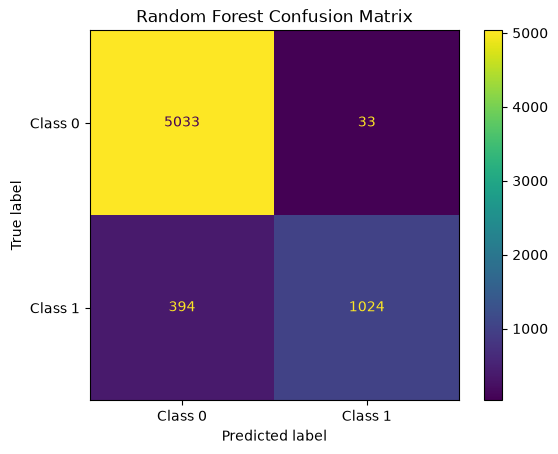

In [37]:
cm = confusion_matrix(y_test, random_forest_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Class 0", "Class 1"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [38]:
from sklearn.metrics import roc_auc_score

logistic_probabilities = logistic_model.predict_proba(X_test_scaled)[:, 1]

decision_tree_probabilities = decision_tree_model.predict_proba(X_test)[:, 1]

random_forest_probabilities = random_forest_model.predict_proba(X_test)[:, 1]

In [39]:
logistic_auc = roc_auc_score(y_test, logistic_probabilities)
decision_tree_auc = roc_auc_score(y_test, decision_tree_probabilities)
random_forest_auc = roc_auc_score(y_test, random_forest_probabilities)

print(f"Logistic Regression ROC-AUC: {logistic_auc:.4f}")
print(f"Decision Tree ROC-AUC: {decision_tree_auc:.4f}")
print(f"Random Forest ROC-AUC: {random_forest_auc:.4f}")

Logistic Regression ROC-AUC: 0.8680
Decision Tree ROC-AUC: 0.8482
Random Forest ROC-AUC: 0.9293


In [41]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        decision_tree_accuracy,
        random_forest_accuracy
    ],
    "ROC-AUC": [
        logistic_auc,
        decision_tree_auc,
        random_forest_auc
    ]
})

results

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.868445,0.867966
1,Decision Tree,0.888186,0.848208
2,Random Forest,0.934146,0.929275


In [42]:
results.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

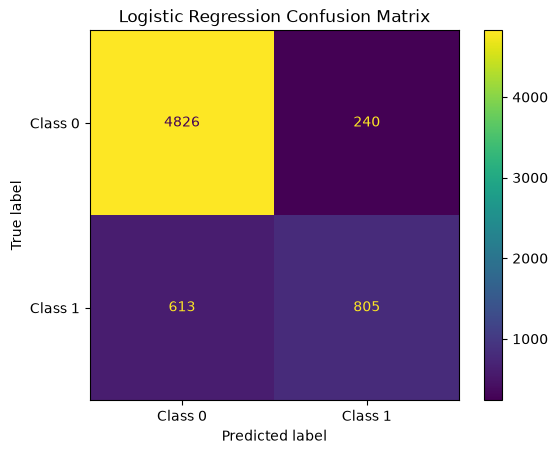

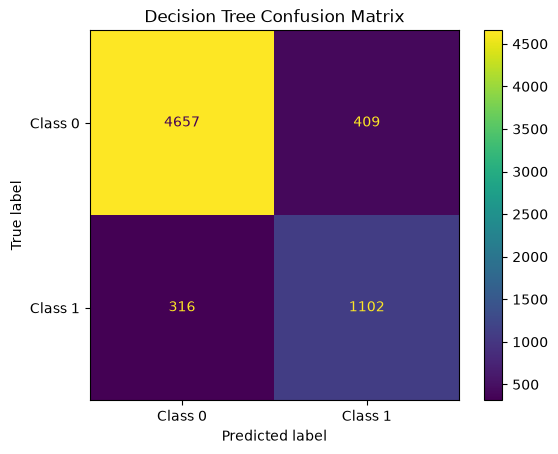

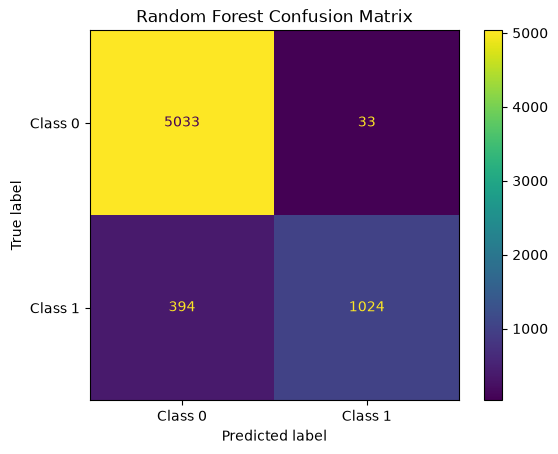

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Logistic Regression
logistic_cm = confusion_matrix(y_test, logistic_predictions)

logistic_disp = ConfusionMatrixDisplay(
    confusion_matrix=logistic_cm,
    display_labels=["Class 0", "Class 1"]
)

logistic_disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()


# Decision Tree
decision_tree_cm = confusion_matrix(y_test, decision_tree_predictions)

decision_tree_disp = ConfusionMatrixDisplay(
    confusion_matrix=decision_tree_cm,
    display_labels=["Class 0", "Class 1"]
)

decision_tree_disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()


# Random Forest
random_forest_cm = confusion_matrix(y_test, random_forest_predictions)

random_forest_disp = ConfusionMatrixDisplay(
    confusion_matrix=random_forest_cm,
    display_labels=["Class 0", "Class 1"]
)

random_forest_disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

### Logistic Regression Confusion Matrix

* **True Class 0, Predicted Class 0:** 4,826
* **True Class 0, Predicted Class 1:** 240
* **True Class 1, Predicted Class 0:** 613
* **True Class 1, Predicted Class 1:** 805

### Decision Tree Confusion Matrix

* **True Class 0, Predicted Class 0:** 4,657
* **True Class 0, Predicted Class 1:** 409
* **True Class 1, Predicted Class 0:** 316
* **True Class 1, Predicted Class 1:** 1,102

### Random Forest Confusion Matrix

* **True Class 0, Predicted Class 0:** 5,033
* **True Class 0, Predicted Class 1:** 33
* **True Class 1, Predicted Class 0:** 394
* **True Class 1, Predicted Class 1:** 1,024


Random Forest achieved the best overall performance among the three evaluated models. It achieved the highest accuracy (93.41%), ROC-AUC score (0.9293), Class 1 precision (97%), and Class 1 F1-score (83%). Although the Decision Tree achieved a slightly higher Class 1 recall of 78% compared to Random Forest's 72%, Random Forest provided the strongest overall balance of classification performance. Therefore, Random Forest was selected as the best-performing model for the next stage of the project.